## WEATHER IMAGE CLASSIFICATION

In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.utils import to_categorical

import warnings
warnings.filterwarnings("ignore")

#### Weather Image Dataset Preprocessing


In [3]:
data = []
labels = []

dataset_path = r"D:\weather\Multi-class Weather Dataset"

classes = os.listdir(dataset_path)

for index, class_name in enumerate(classes):

    class_path = os.path.join(dataset_path, class_name)

    for file in os.listdir(class_path):

        if file.lower().endswith(('.jpg', '.jpeg', '.png')):

            img_path = os.path.join(class_path, file)

            img = Image.open(img_path)
            img = img.resize((128,128))
            img = np.array(img) / 255.0

            if img.shape == (128,128,3):
                data.append(img)
                labels.append(index)

In [6]:
data = np.array(data)
labels = np.array(labels)

print("Data shape:", data.shape)
print("Labels shape:", labels.shape)

Data shape: (1120, 128, 128, 3)
Labels shape: (1120,)


### Visualization

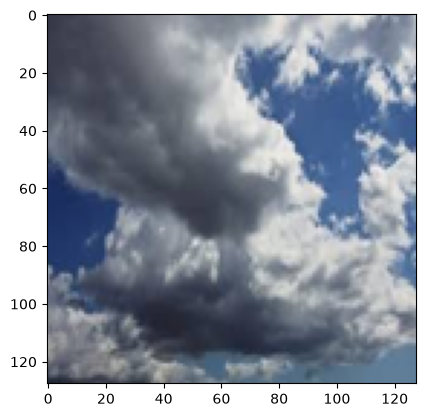

In [7]:
plt.imshow(data[67])

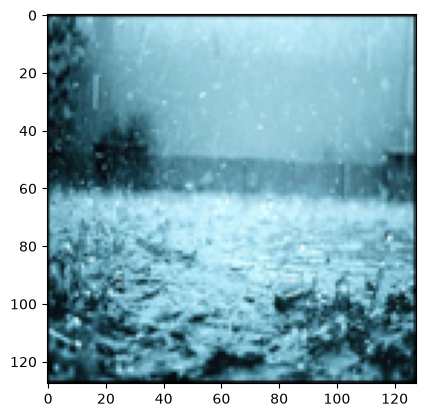

In [8]:
plt.imshow(data[301])

In [9]:
from tensorflow.keras.utils import to_categorical

labels = to_categorical(labels)

print(labels.shape)

(1120, 4)


## Data Splitting

In [10]:
x_train, x_test, y_train, y_test = train_test_split(
    data,
    labels,
    test_size=0.2,
    shuffle=True,
    random_state=42
)

### Model creaton using Sequential Method

In [11]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense, Dropout, BatchNormalization

model = Sequential()

# First Convolution Layer
model.add(Conv2D(32, (3,3), activation='relu',
                 input_shape=(128,128,3), padding='same'))
model.add(BatchNormalization())
model.add(MaxPooling2D((2,2)))

# Second Convolution Layer
model.add(Conv2D(64, (3,3), activation='relu', padding='same'))
model.add(BatchNormalization())
model.add(MaxPooling2D((2,2)))

# Third Convolution Layer
model.add(Conv2D(128, (3,3), activation='relu', padding='same'))
model.add(BatchNormalization())
model.add(MaxPooling2D((2,2)))

# Fully Connected Layer
model.add(Flatten())
model.add(Dense(256, activation='relu'))
model.add(Dropout(0.5))

# Output Layer (4 weather classes)
model.add(Dense(4, activation='softmax'))

print(model.summary())

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     8,388,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,484,036 (32.36 MB)

 Trainable params: 8,483,588 (32.36 MB)

 Non-trainable params: 448 (1.75 KB)

None


### Model Configuration

In [12]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [13]:
x_train.shape

(896, 128, 128, 3)

In [21]:
y_train.shape

(896, 4)

### Model Training

In [15]:
history = model.fit(
    x_train, y_train,
    epochs=18,
    batch_size=32,
    verbose=1,
    validation_data=(x_test, y_test))

Epoch 1/18
28/28 ━━━━━━━━━━━━━━━━━━━━ 47s 1s/step - accuracy: 0.7344 - loss: 5.9990 - val_accuracy: 0.6384 - val_loss: 1.9626
Epoch 2/18
28/28 ━━━━━━━━━━━━━━━━━━━━ 38s 1s/step - accuracy: 0.8158 - loss: 2.8094 - val_accuracy: 0.5625 - val_loss: 2.1793
Epoch 3/18
28/28 ━━━━━━━━━━━━━━━━━━━━ 41s 1s/step - accuracy: 0.8884 - loss: 1.3579 - val_accuracy: 0.3348 - val_loss: 5.1690
Epoch 4/18
28/28 ━━━━━━━━━━━━━━━━━━━━ 38s 1s/step - accuracy: 0.9018 - loss: 0.7255 - val_accuracy: 0.3259 - val_loss: 6.6418
Epoch 5/18
28/28 ━━━━━━━━━━━━━━━━━━━━ 38s 1s/step - accuracy: 0.9085 - loss: 0.5330 - val_accuracy: 0.3438 - val_loss: 4.0668
Epoch 6/18
28/28 ━━━━━━━━━━━━━━━━━━━━ 38s 1s/step - accuracy: 0.9085 - loss: 0.6357 - val_accuracy: 0.3705 - val_loss: 6.3958
Epoch 7/18
28/28 ━━━━━━━━━━━━━━━━━━━━ 39s 1s/step - accuracy: 0.8806 - loss: 1.0083 - val_accuracy: 0.5223 - val_loss: 2.6510
Epoch 8/18
28/28 ━━━━━━━━━━━━━━━━━━━━ 36s 1s/step - accuracy: 0.8873 - loss: 0.7240 - val_accuracy: 0.6339 - val_loss:

### Model Evaluation

In [22]:
score = model.evaluate(x_test, y_test, batch_size=64)
print("\nTest accuracy: %.2f%%" % (100.0 * score[1]))

4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 333ms/step - accuracy: 0.8214 - loss: 1.3738

Test accuracy: 82.14%


### PREDICTION

In [23]:
img_path = r"D:\weather\Multi-class Weather Dataset\Sunrise\sunrise29.jpg"
img = Image.open(img_path)
img = img.resize((128,128))
img = np.array(img) / 255.0   # 🔥 same preprocessing

img = np.expand_dims(img, axis=0)  # shape (1,128,128,3)

prediction = model.predict(img)
pred_class = np.argmax(prediction)
classes = ["cloudy","rainy","shine","sunrise"]
print("Predicted Weather")
print(classes[pred_class])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
Predicted Weather
sunrise
